# VinDatathon 2026 — Phần 3: Forecasting Pipeline

## 0. Setup

In [1]:
# !pip install lightgbm prophet --quiet

import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.linear_model import Ridge
from prophet import Prophet
import matplotlib.pyplot as plt
import warnings, logging
import os
import sys
import io
import warnings
warnings.filterwarnings('ignore')
logging.getLogger('cmdstanpy').setLevel(logging.WARNING)
logging.getLogger('prophet').setLevel(logging.WARNING)

In [2]:
DATA_DIR = r'../raw'
OUT_DIR  = r'../tableau_data'
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load dữ liệu

In [3]:
sales = pd.read_csv(os.path.join(DATA_DIR,'sales.csv'), parse_dates=['Date'])
sales['Y']  = sales.Date.dt.year
sales['Q']  = sales.Date.dt.quarter
sales['M']  = sales.Date.dt.month
sales['DOW']= sales.Date.dt.dayofweek
sales['day']= sales.Date.dt.day

print(sales.shape, sales.Date.min().date(), '->', sales.Date.max().date())
sales.head()

(3833, 8) 2012-07-04 -> 2022-12-31


,Date,Revenue,COGS,Y,Q,M,DOW,day
0,2012-07-04,5123547.94,3982991.19,2012,3,7,2,4
1,2012-07-05,2751773.45,2150580.23,2012,3,7,3,5
2,2012-07-06,3054029.42,2517632.84,2012,3,7,4,6
3,2012-07-07,2667930.94,2108246.62,2012,3,7,5,7
4,2012-07-08,2360851.90,1808622.79,2012,3,7,6,8


## 2. EDA

### 2.1 Timeline Revenue & COGS

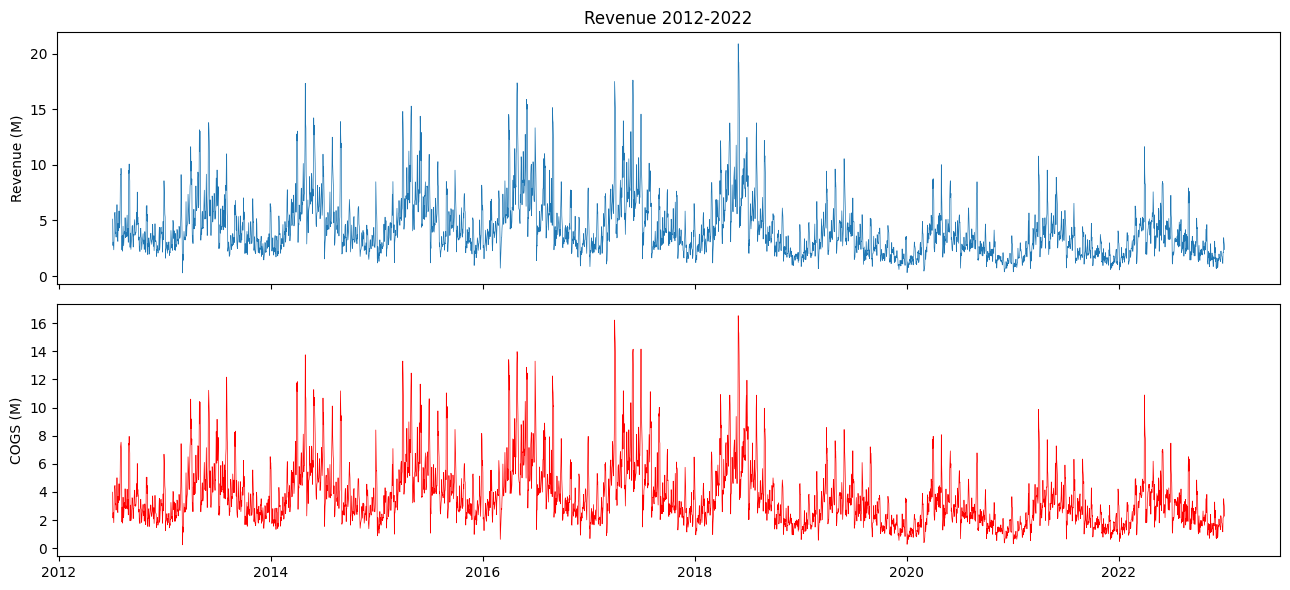

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(sales.Date, sales.Revenue/1e6, lw=0.5)
axes[0].set_ylabel('Revenue (M)'); axes[0].set_title('Revenue 2012-2022')
axes[1].plot(sales.Date, sales.COGS/1e6, lw=0.5, color='red')
axes[1].set_ylabel('COGS (M)')
plt.tight_layout(); plt.show()

### 2.2 Monthly seasonality

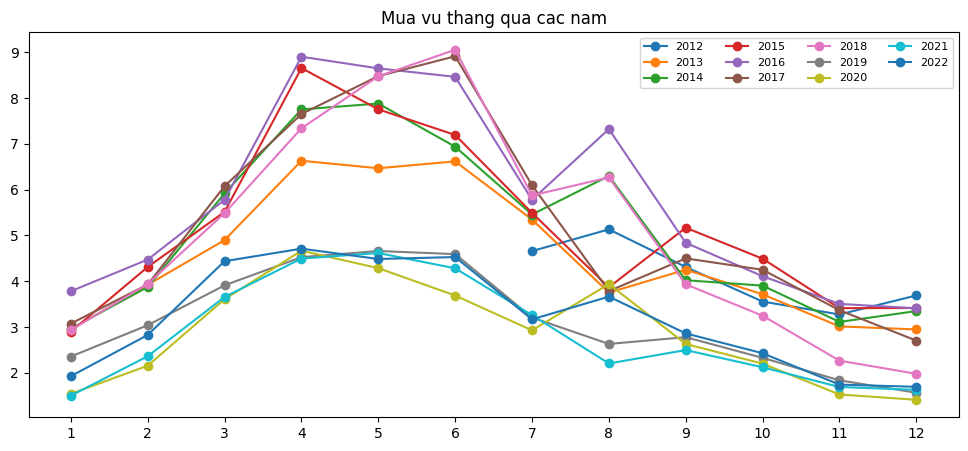

In [5]:
monthly = sales.groupby(['Y','M']).Revenue.mean().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
for y in sorted(sales.Y.unique()):
    d = monthly[monthly.Y == y]
    ax.plot(d.M, d.Revenue/1e6, marker='o', label=str(y))
ax.set_xticks(range(1,13)); ax.legend(ncol=4, fontsize=8)
ax.set_title('Mua vu thang qua cac nam')
plt.show()

### 2.3 Quarterly margin (Q3 zigzag chẵn/lẻ)

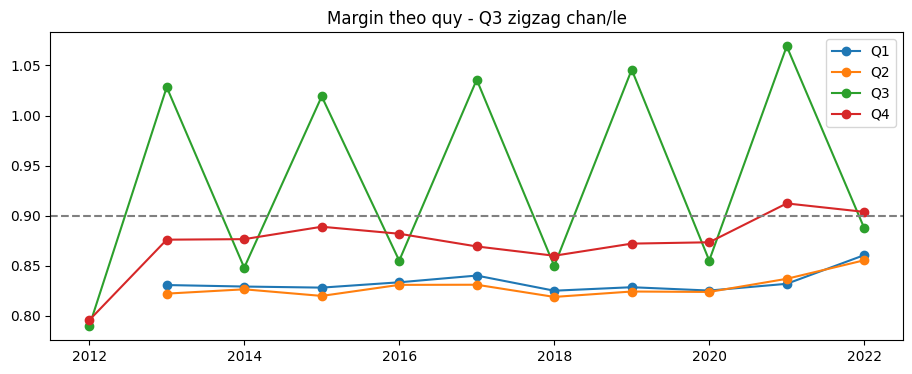

In [6]:
q_marg = sales.groupby(['Y','Q']).apply(
    lambda d: d.COGS.sum()/d.Revenue.sum(), include_groups=False).reset_index()
q_marg.columns = ['Y','Q','margin']

fig, ax = plt.subplots(figsize=(11, 4))
for q in [1,2,3,4]:
    d = q_marg[q_marg.Q == q]
    ax.plot(d.Y, d.margin, marker='o', label=f'Q{q}')
ax.axhline(0.9, color='gray', ls='--')
ax.set_title('Margin theo quy - Q3 zigzag chan/le')
ax.legend(); plt.show()

## 3. Feature Engineering — calendar-only


In [7]:
PROMO_SCHEDULE = [
    ('spring_sale',   3, 18, 30, 12, True),
    ('mid_year',      6, 23, 29, 18, True),
    ('fall_launch',   8, 30, 32, 10, True),
    ('year_end',     11, 18, 45, 20, True),
    ('urban_blowout', 7, 30, 33, None, 'odd'),
    ('rural_special', 1, 30, 30, 15,   'odd'),
]

TET_DATES = {
    2013:'2013-02-10', 2014:'2014-01-31', 2015:'2015-02-19',
    2016:'2016-02-08', 2017:'2017-01-28', 2018:'2018-02-16',
    2019:'2019-02-05', 2020:'2020-01-25', 2021:'2021-02-12',
    2022:'2022-02-01', 2023:'2023-01-22', 2024:'2024-02-10',
}

VN_FIXED_HOLIDAYS = [
    (1,1,'new_year'), (3,8,'womens_day'), (4,30,'reunification'),
    (5,1,'labor_day'), (9,2,'national_day'), (10,20,'vn_womens_day'),
    (11,11,'dd_1111'), (12,12,'dd_1212'),
    (12,24,'christmas_eve'), (12,25,'christmas'),
]

In [42]:
def build_features(dates):
    df = pd.DataFrame({'Date': dates})
    d = df['Date']

    # Calendar
    df['year']    = d.dt.year
    df['month']   = d.dt.month
    df['day']     = d.dt.day
    df['dow']     = d.dt.dayofweek
    df['doy']     = d.dt.dayofyear
    df['quarter'] = d.dt.quarter
    df['is_weekend']    = (df['dow']>=5).astype(int)
    df['days_to_eom']   = d.dt.days_in_month - df['day']
    df['days_from_som'] = df['day'] - 1
    df['dim']           = d.dt.days_in_month

    # Edge of month
    for k in [1,2,3]:
        df[f'is_last{k}']  = (df['days_to_eom']  <= k-1).astype(int)
        df[f'is_first{k}'] = (df['days_from_som'] <= k-1).astype(int)

    # Trend + regime
    df['t_days']  = (d - pd.Timestamp('2020-01-01')).dt.days
    df['t_years'] = df['t_days']/365.25
    df['regime_pre2019']  = (df['year']<=2018).astype(int)
    df['regime_2019']     = (df['year']==2019).astype(int)
    df['regime_post2019'] = (df['year']>=2020).astype(int)

    # Fourier
    TAU = 2*np.pi
    for k in (1,2,3,4,5):
        df[f'sin_y{k}'] = np.sin(TAU*k*df['doy']/365.25)
        df[f'cos_y{k}'] = np.cos(TAU*k*df['doy']/365.25)
    for k in (1,2):
        df[f'sin_w{k}'] = np.sin(TAU*k*df['dow']/7.0)
        df[f'cos_w{k}'] = np.cos(TAU*k*df['dow']/7.0)
    for k in (1,2):
        df[f'sin_m{k}'] = np.sin(TAU*k*(df['day']-1)/df['dim'])
        df[f'cos_m{k}'] = np.cos(TAU*k*(df['day']-1)/df['dim'])

    # Holidays
    for (m, dd_, name) in VN_FIXED_HOLIDAYS:
        df[f'hol_{name}'] = ((df['month']==m) & (df['day']==dd_)).astype(int)

    # Tet distance
    tet_lut = {y: pd.Timestamp(v) for y,v in TET_DATES.items()}
    def nearest_tet_diff(dd):
        cands = [tet_lut.get(dd.year), tet_lut.get(dd.year-1), tet_lut.get(dd.year+1)]
        cands = [c for c in cands if c is not None]
        valid = [(dd-c).days for c in cands if abs((dd-c).days)<=45]
        return min(valid) if valid else 999
    diffs = np.array([nearest_tet_diff(dd) for dd in d])
    df['tet_days_diff'] = diffs
    df['tet_in_7']      = (np.abs(diffs)<=7).astype(int)
    df['tet_in_14']     = (np.abs(diffs)<=14).astype(int)
    df['tet_before_7']  = ((diffs>=-7) & (diffs<0)).astype(int)
    df['tet_after_7']   = ((diffs>0) & (diffs<=7)).astype(int)
    df['tet_on']        = (diffs==0).astype(int)

    # Black Friday
    def is_bf(dd):
        if dd.month != 11: return 0
        last = pd.Timestamp(year=dd.year, month=11, day=30)
        last_fri = last - pd.Timedelta(days=(last.dayofweek - 4) % 7)
        return int(dd == last_fri)
    df['hol_black_friday'] = [is_bf(dd) for dd in d]

    # Promo windows
    yrs = sorted(set(df['year'].tolist()))
    for (name, sm, sd, dur, disc, recur) in PROMO_SCHEDULE:
        in_prom = np.zeros(len(df), dtype=int)
        since   = np.full(len(df), -1.0)
        until   = np.full(len(df), -1.0)
        discount= np.zeros(len(df))
        for y in range(min(yrs)-1, max(yrs)+2):
            if recur=='odd' and y%2==0: continue
            start = pd.Timestamp(year=y, month=sm, day=sd)
            end   = start + pd.Timedelta(days=dur)
            mask  = (d>=start) & (d<=end)
            in_prom[mask] = 1
            since[mask]   = (d[mask]-start).dt.days
            until[mask]   = (end-d[mask]).dt.days
            discount[mask]= disc or 0
        df[f'promo_{name}']       = in_prom
        df[f'promo_{name}_since'] = since
        df[f'promo_{name}_until'] = until
        df[f'promo_{name}_disc']  = discount

    df['is_odd_year'] = (df['year'] % 2).astype(int)
    return df

print('Test:', build_features(pd.date_range('2023-01-01','2023-01-05')).shape)

Test: (5, 82)


## 4. Chuẩn bị data train + test

In [43]:
feat = build_features(sales['Date'])
feat['Revenue'] = sales['Revenue'].values
feat['COGS']    = sales['COGS'].values

test_dates = pd.date_range('2023-01-01', '2024-07-01', freq='D')
test_df = build_features(test_dates)

NON_FEATURES = {'Date','Revenue','COGS'}
cols = [c for c in feat.columns if c not in NON_FEATURES]

X_tr = feat[cols].values.astype(float)
X_te = test_df[cols].values.astype(float)
y_rev = np.log(feat['Revenue'].values)
y_cog = np.log(feat['COGS'].values)
years = feat['Date'].dt.year.values

print(f'Training: {X_tr.shape}, Test: {X_te.shape}, Features: {len(cols)}')

Training: (3833, 81), Test: (548, 81), Features: 81


## 5. Sample weight (high_era)

Ưu tiên 2014-2018 vì đây là vùng có seasonality rõ nhất.

In [44]:
w_full = np.full(len(years), 0.01)
w_full[(years>=2014) & (years<=2018)] = 1.0
print(f'Days with w=1.0: {(w_full==1.0).sum()}, w=0.01: {(w_full==0.01).sum()}')

Days with w=1.0: 1826, w=0.01: 2007


## 6. M1 — Ridge Regression

In [45]:
def train_ridge(X_train, y_train, alpha=3.0):
    mu = X_train.mean(axis=0)
    sigma = X_train.std(axis=0).replace(0, 1)
    Xs = (X_train - mu) / sigma
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(Xs, y_train)
    return m, (mu, sigma)

def predict_ridge(model, X_test, stats):
    mu, sigma = stats
    return model.predict((X_test - mu) / sigma)

ridge_rev, st_r = train_ridge(pd.DataFrame(X_tr, columns=cols), y_rev)
ridge_cog, st_c = train_ridge(pd.DataFrame(X_tr, columns=cols), y_cog)

p_rd_rev = np.exp(predict_ridge(ridge_rev, pd.DataFrame(X_te, columns=cols), st_r))
p_rd_cog = np.exp(predict_ridge(ridge_cog, pd.DataFrame(X_te, columns=cols), st_c))

print(f'Ridge Revenue: {p_rd_rev.mean():,.0f}')
print(f'Ridge COGS:    {p_rd_cog.mean():,.0f}')

Ridge Revenue: 3,030,994
Ridge COGS:    2,721,462


## 7. M2 — LightGBM (high_era)

Two-stage: early stopping → retrain với best_iteration.

In [52]:
import optuna
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import mean_absolute_error


BASE_LGB_PARAMS = dict(
    objective='regression',
    metric='mae',
    seed=42,
    verbosity=-1,
)


def tune_lgb_optuna(X, y, w, dates, n_trials=50, num_boost_es=5000, early_stop=300):
    intern = pd.Timestamp('2022-07-04')

    fit_idx = (dates <= intern).values
    ins_idx = (dates > intern).values

    X_train = X[fit_idx]
    y_train = y[fit_idx]
    w_train = w[fit_idx]

    X_valid = X[ins_idx]
    y_valid = y[ins_idx]
    w_valid = w[ins_idx]

    def objective(trial):
        params = {
            **BASE_LGB_PARAMS,

            "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.08, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 16, 256),
            "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 10, 200),

            "feature_fraction": trial.suggest_float("feature_fraction", 0.6, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.6, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),

            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),

            "max_depth": trial.suggest_int("max_depth", 3, 12),
            "min_gain_to_split": trial.suggest_float("min_gain_to_split", 0.0, 1.0),
        }

        train_set = lgb.Dataset(X_train, y_train, weight=w_train)
        valid_set = lgb.Dataset(X_valid, y_valid, weight=w_valid)

        model = lgb.train(
            params,
            train_set,
            num_boost_round=num_boost_es,
            valid_sets=[valid_set],
            callbacks=[
                lgb.early_stopping(early_stop, verbose=False),
                lgb.log_evaluation(0)
            ]
        )

        pred = model.predict(X_valid, num_iteration=model.best_iteration)
        mae = mean_absolute_error(y_valid, pred, sample_weight=w_valid)

        return mae
    sampler = optuna.samplers.TPESampler(seed=36)
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials)

    return study

In [53]:
def train_lgb_with_optuna(X, y, w, dates, n_trials=50, num_boost_es=5000, early_stop=300):
    study = tune_lgb_optuna(
        X=X,
        y=y,
        w=w,
        dates=dates,
        n_trials=n_trials,
        num_boost_es=num_boost_es,
        early_stop=early_stop
    )

    best_params = {
        **BASE_LGB_PARAMS,
        **study.best_params
    }

    intern = pd.Timestamp('2022-07-04')
    fit_idx = (dates <= intern).values
    ins_idx = (dates > intern).values

    bk = lgb.train(
        best_params,
        lgb.Dataset(X[fit_idx], y[fit_idx], weight=w[fit_idx]),
        num_boost_round=num_boost_es,
        valid_sets=[
            lgb.Dataset(X[ins_idx], y[ins_idx], weight=w[ins_idx])
        ],
        callbacks=[
            lgb.early_stopping(early_stop, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    final_model = lgb.train(
        best_params,
        lgb.Dataset(X, y, weight=w),
        num_boost_round=bk.best_iteration
    )

    return final_model, bk.best_iteration, study

In [54]:
print('Train LGB Revenue with Optuna...')

bf_rev, it_rev, study_rev = train_lgb_with_optuna(
    X=X_tr,
    y=y_rev,
    w=w_full,
    dates=feat["Date"],
    n_trials=50,
    num_boost_es=5000,
    early_stop=300
)

print(f'  best_iter={it_rev}')
print(f'  best_mae={study_rev.best_value:.5f}')
print(f'  best_params={study_rev.best_params}')


print('Train LGB COGS with Optuna...')

bf_cog, it_cog, study_cog = train_lgb_with_optuna(
    X=X_tr,
    y=y_cog,
    w=w_full,
    dates=feat["Date"],
    n_trials=50,
    num_boost_es=5000,
    early_stop=300
)

print(f'  best_iter={it_cog}')
print(f'  best_mae={study_cog.best_value:.5f}')
print(f'  best_params={study_cog.best_params}')


p_lgb_rev = np.exp(bf_rev.predict(X_te, num_iteration=it_rev))
p_lgb_cog = np.exp(bf_cog.predict(X_te, num_iteration=it_cog))

print(f'LGB Revenue: {p_lgb_rev.mean():,.0f}')
print(f'LGB COGS:    {p_lgb_cog.mean():,.0f}')

[I 2026-04-29 07:24:53,254] A new study created in memory with name: no-name-a38cf424-e1eb-40b5-b1db-da21ee657768


Train LGB Revenue with Optuna...


[I 2026-04-29 07:24:53,651] Trial 0 finished with value: 0.26784499981149357 and parameters: {'learning_rate': 0.007827410351311754, 'num_leaves': 104, 'min_data_in_leaf': 195, 'feature_fraction': 0.9127228509756488, 'bagging_fraction': 0.7237564109350274, 'bagging_freq': 4, 'lambda_l1': 0.0001341617329755252, 'lambda_l2': 0.05134079762151322, 'max_depth': 9, 'min_gain_to_split': 0.3036811193642225}. Best is trial 0 with value: 0.26784499981149357.
[I 2026-04-29 07:24:53,875] Trial 1 finished with value: 0.2895218324579923 and parameters: {'learning_rate': 0.008949929463686007, 'num_leaves': 69, 'min_data_in_leaf': 163, 'feature_fraction': 0.9006428399768981, 'bagging_fraction': 0.6524497318578479, 'bagging_freq': 9, 'lambda_l1': 2.670030249150076e-08, 'lambda_l2': 0.020842912451696862, 'max_depth': 9, 'min_gain_to_split': 0.47217079951050644}. Best is trial 0 with value: 0.26784499981149357.
[I 2026-04-29 07:24:54,014] Trial 2 finished with value: 0.22953564960320186 and parameters: {

  best_iter=214
  best_mae=0.18117
  best_params={'learning_rate': 0.06779680956339147, 'num_leaves': 256, 'min_data_in_leaf': 48, 'feature_fraction': 0.8117090456539445, 'bagging_fraction': 0.9731548986821638, 'bagging_freq': 4, 'lambda_l1': 1.2986949129877239e-05, 'lambda_l2': 3.858041293132025e-08, 'max_depth': 6, 'min_gain_to_split': 0.008161400794672702}
Train LGB COGS with Optuna...


[I 2026-04-29 07:25:10,985] Trial 1 finished with value: 0.28900831164082885 and parameters: {'learning_rate': 0.0081059268948782, 'num_leaves': 229, 'min_data_in_leaf': 60, 'feature_fraction': 0.8302375154845678, 'bagging_fraction': 0.9959293197287148, 'bagging_freq': 7, 'lambda_l1': 0.13955300066579207, 'lambda_l2': 0.008760502162428276, 'max_depth': 8, 'min_gain_to_split': 0.8948540108253218}. Best is trial 0 with value: 0.24355947455492433.
[I 2026-04-29 07:25:11,060] Trial 2 finished with value: 0.2756205979893166 and parameters: {'learning_rate': 0.07827719423065431, 'num_leaves': 18, 'min_data_in_leaf': 185, 'feature_fraction': 0.6045494505446595, 'bagging_fraction': 0.9579750867705799, 'bagging_freq': 5, 'lambda_l1': 2.3409061647357966e-06, 'lambda_l2': 1.9996461876034048e-05, 'max_depth': 3, 'min_gain_to_split': 0.9163648222344295}. Best is trial 0 with value: 0.24355947455492433.
[I 2026-04-29 07:25:11,175] Trial 3 finished with value: 0.28356257231211557 and parameters: {'le

  best_iter=1332
  best_mae=0.18105
  best_params={'learning_rate': 0.028135070969313298, 'num_leaves': 155, 'min_data_in_leaf': 29, 'feature_fraction': 0.7302800055031109, 'bagging_fraction': 0.7407424799038277, 'bagging_freq': 8, 'lambda_l1': 2.427572046779676e-05, 'lambda_l2': 0.046266979574940865, 'max_depth': 3, 'min_gain_to_split': 0.00013750854448883049}
LGB Revenue: 3,363,569
LGB COGS:    2,878,091


## 8. M3 — Prophet (post-regime only)

In [55]:
def build_promo_regressors(dates):
    full = build_features(dates)
    promo_cols = [c for c in full.columns
                  if c.startswith('promo_') and c.count('_') == 2]
    return full[['Date'] + promo_cols].rename(columns={'Date':'ds'})

def fit_prophet(train_df, post_regime_only=True):
    if post_regime_only:
        train_df = train_df[train_df['ds'] >= '2020-01-01']
    m = Prophet( yearly_seasonality=True, weekly_seasonality=True,
                daily_seasonality=False,
                seasonality_mode='multiplicative',
                changepoint_prior_scale=0.05)
    for col in [c for c in train_df.columns if c.startswith('promo_')]:
        m.add_regressor(col)
    m.fit(train_df)
    return m

In [56]:
print('Train Prophet Revenue...')
tdf_r = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['Revenue'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_r = fit_prophet(tdf_r)

print('Train Prophet COGS...')
tdf_c = pd.DataFrame({'ds': sales['Date'], 'y': np.log(sales['COGS'])}) \
          .merge(build_promo_regressors(sales['Date']), on='ds')
mp_c = fit_prophet(tdf_c)

vdf = pd.DataFrame({'ds': test_df['Date']}) \
        .merge(build_promo_regressors(test_df['Date']), on='ds')
p_pr_rev = np.exp(mp_r.predict(vdf)['yhat'].values)
p_pr_cog = np.exp(mp_c.predict(vdf)['yhat'].values)

print(f'Prophet Revenue: {p_pr_rev.mean():,.0f}')
print(f'Prophet COGS:    {p_pr_cog.mean():,.0f}')

Train Prophet Revenue...


07:25:26 - cmdstanpy - INFO - Chain [1] start processing
07:25:26 - cmdstanpy - INFO - Chain [1] done processing


Train Prophet COGS...


07:25:26 - cmdstanpy - INFO - Chain [1] start processing
07:25:26 - cmdstanpy - INFO - Chain [1] done processing


Prophet Revenue: 3,550,361
Prophet COGS:    3,169,960


## 9. Q-Specialists — 8 LightGBM (4 quý × 2 target)

Mỗi specialist boost 2× weight cho quý trọng điểm. Khi predict, ghép theo quý của test date.

In [57]:
def train_q_specialist(X, y, w_base, target_q, q_boost=2.0):
    Q_train = feat['Date'].dt.quarter.values
    w = w_base.copy()
    w[Q_train == target_q] *= q_boost
    bf, _,_ = train_lgb_with_optuna(X, y, w, dates=feat["Date"],num_boost_es=3000, early_stop=200)
    return bf

spec_rev = {}
spec_cog = {}
for q in [1, 2, 3, 4]:
    print(f'Spec_Q{q} Revenue...')
    bf = train_q_specialist(X_tr, y_rev, w_full, q)
    spec_rev[q] = np.exp(bf.predict(X_te))

    print(f'Spec_Q{q} COGS...')
    bf = train_q_specialist(X_tr, y_cog, w_full, q)
    spec_cog[q] = np.exp(bf.predict(X_te))

print('Done 8 specialists.')

[I 2026-04-29 07:25:27,164] A new study created in memory with name: no-name-d791e438-5b58-4288-b6b4-3dfd082a9e45


Spec_Q1 Revenue...


[I 2026-04-29 07:25:28,608] Trial 0 finished with value: 0.19393799097742423 and parameters: {'learning_rate': 0.007745919266828841, 'num_leaves': 38, 'min_data_in_leaf': 168, 'feature_fraction': 0.6179166729468655, 'bagging_fraction': 0.6995538754113036, 'bagging_freq': 1, 'lambda_l1': 6.4057604856715e-07, 'lambda_l2': 4.7106173422848225e-05, 'max_depth': 9, 'min_gain_to_split': 0.058325112487358055}. Best is trial 0 with value: 0.19393799097742423.
[I 2026-04-29 07:25:28,686] Trial 1 finished with value: 0.2705392888397495 and parameters: {'learning_rate': 0.0629599286904521, 'num_leaves': 252, 'min_data_in_leaf': 158, 'feature_fraction': 0.748415470328196, 'bagging_fraction': 0.6709687602489077, 'bagging_freq': 3, 'lambda_l1': 7.701709589991456e-08, 'lambda_l2': 1.1475643562654448e-08, 'max_depth': 6, 'min_gain_to_split': 0.31662252270175617}. Best is trial 0 with value: 0.19393799097742423.
[I 2026-04-29 07:25:28,761] Trial 2 finished with value: 0.2524542761000223 and parameters: 

Spec_Q1 COGS...


[I 2026-04-29 07:25:59,245] Trial 0 finished with value: 0.31434881514372276 and parameters: {'learning_rate': 0.008709773547499933, 'num_leaves': 167, 'min_data_in_leaf': 91, 'feature_fraction': 0.6650741268617145, 'bagging_fraction': 0.996738732589231, 'bagging_freq': 10, 'lambda_l1': 7.106142755218482, 'lambda_l2': 2.6895448553309844e-08, 'max_depth': 8, 'min_gain_to_split': 0.3710061121264433}. Best is trial 0 with value: 0.31434881514372276.
[I 2026-04-29 07:25:59,345] Trial 1 finished with value: 0.23397481273545934 and parameters: {'learning_rate': 0.07019840396191952, 'num_leaves': 171, 'min_data_in_leaf': 191, 'feature_fraction': 0.736552305000678, 'bagging_fraction': 0.6177271724505334, 'bagging_freq': 7, 'lambda_l1': 4.1513276662865045e-07, 'lambda_l2': 4.652894092692661e-06, 'max_depth': 3, 'min_gain_to_split': 0.14309618267387947}. Best is trial 1 with value: 0.23397481273545934.
[I 2026-04-29 07:25:59,511] Trial 2 finished with value: 0.20182664859912477 and parameters: {

...

Spec_Q4 Revenue...


[I 2026-04-29 07:28:19,902] Trial 1 finished with value: 0.2351263741497312 and parameters: {'learning_rate': 0.07365211664360902, 'num_leaves': 18, 'min_data_in_leaf': 39, 'feature_fraction': 0.7190073389855409, 'bagging_fraction': 0.9897367991918717, 'bagging_freq': 7, 'lambda_l1': 0.02135414285510927, 'lambda_l2': 0.0043277403755107675, 'max_depth': 3, 'min_gain_to_split': 0.6925624819559358}. Best is trial 0 with value: 0.2109330518312945.
[I 2026-04-29 07:28:19,987] Trial 2 finished with value: 0.21553392950261765 and parameters: {'learning_rate': 0.05835767975268289, 'num_leaves': 162, 'min_data_in_leaf': 20, 'feature_fraction': 0.9291894561312929, 'bagging_fraction': 0.6696866143422306, 'bagging_freq': 5, 'lambda_l1': 7.006507386073409e-06, 'lambda_l2': 1.1446061552953956e-07, 'max_depth': 4, 'min_gain_to_split': 0.319234815203447}. Best is trial 0 with value: 0.2109330518312945.
[I 2026-04-29 07:28:20,066] Trial 3 finished with value: 0.22888347053452654 and parameters: {'learn

Spec_Q4 COGS...


[I 2026-04-29 07:29:00,917] Trial 0 finished with value: 0.20171396585519374 and parameters: {'learning_rate': 0.01909036610302691, 'num_leaves': 162, 'min_data_in_leaf': 12, 'feature_fraction': 0.6121102576478278, 'bagging_fraction': 0.9452522468162339, 'bagging_freq': 6, 'lambda_l1': 8.012629509276018e-06, 'lambda_l2': 5.231459477940195e-07, 'max_depth': 7, 'min_gain_to_split': 0.13194830245487987}. Best is trial 0 with value: 0.20171396585519374.
[I 2026-04-29 07:29:01,000] Trial 1 finished with value: 0.26268161559899433 and parameters: {'learning_rate': 0.0380618872690295, 'num_leaves': 29, 'min_data_in_leaf': 198, 'feature_fraction': 0.7706617611223037, 'bagging_fraction': 0.7900429595807422, 'bagging_freq': 4, 'lambda_l1': 8.34584282664054e-06, 'lambda_l2': 1.528069790411362e-06, 'max_depth': 9, 'min_gain_to_split': 0.9845278495056544}. Best is trial 0 with value: 0.20171396585519374.
[I 2026-04-29 07:29:01,156] Trial 2 finished with value: 0.22400050365159538 and parameters: {'

Done 8 specialists.


In [58]:
# Ghep theo quy cua test date
Q_test = test_df['Date'].dt.quarter.values
lgb_spec_rev = np.zeros(len(test_dates))
lgb_spec_cog = np.zeros(len(test_dates))
for q in [1,2,3,4]:
    mask = Q_test == q
    lgb_spec_rev[mask] = spec_rev[q][mask]
    lgb_spec_cog[mask] = spec_cog[q][mask]

## 10. Ensemble 3-tầng + Calibration

In [ ]:
ALPHA = 0.60   # specialist vs base LGB
CR    = 1.26   # calibration Revenue
CC    = 1.36   # calibration COGS

# Tang 1: LGB blend
lgb_blend_rev = ALPHA * lgb_spec_rev + (1 - ALPHA) * p_lgb_rev
lgb_blend_cog = ALPHA * lgb_spec_cog + (1 - ALPHA) * p_lgb_cog

# Tang 2: 3-way blend
raw_rev = 0.10 * p_pr_rev + 0.10 * p_rd_rev + 0.80 * lgb_blend_rev
raw_cog = 0.10 * p_pr_cog + 0.10 * p_rd_cog + 0.80 * lgb_blend_cog

# Tang 3: calibration
final_rev = CR * raw_rev
final_cog = CC * raw_cog

print(f'Final Revenue: {final_rev.mean():,.0f}')
print(f'Final COGS:    {final_cog.mean():,.0f}')

Final Revenue: 3,949,878
Final COGS:    3,999,089


## 11. Save submission

In [60]:
sub = pd.DataFrame({
    'Date':    test_df['Date'].dt.strftime('%Y-%m-%d').values,
    'Revenue': np.array(final_rev).ravel(),
    'COGS':    np.array(final_cog).ravel(),
})

out_path = os.path.join(OUT_DIR,'submission.csv')
sub.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
sub.head()

Saved: ../tableau_data\submission.csv


,Date,Revenue,COGS
0,2023-01-01,2.651921e+06,2.964203e+06
1,2023-01-02,1.731749e+06,1.634847e+06
2,2023-01-03,1.327917e+06,1.196400e+06
3,2023-01-04,1.063063e+06,9.732990e+05
4,2023-01-05,1.142070e+06,1.123967e+06


## 12. (Bonus) — Mean-preserving margin fix

Hậu xử lý kéo Q3 margin về historical, giữ nguyên cog_mean toàn cục. Cải thiện thêm ~1K LB.

In [61]:
target_cog_mean = sub.COGS.mean()

recent_margin = {q: sales[(sales.Q==q) & (sales.Y>=2020)].COGS.sum() /
                    sales[(sales.Q==q) & (sales.Y>=2020)].Revenue.sum()
                 for q in [1,2,3,4]}

sub_v57 = sub.copy()
sub_v57['Date_dt'] = pd.to_datetime(sub_v57['Date'])
sub_v57['Q'] = sub_v57['Date_dt'].dt.quarter

BETA = 0.30
for q in [1,2,3,4]:
    mask = sub_v57.Q == q
    historical_cog = sub_v57.loc[mask, 'Revenue'] * recent_margin[q]
    sub_v57.loc[mask, 'COGS'] = (1-BETA)*sub_v57.loc[mask, 'COGS'] + BETA*historical_cog

scale = target_cog_mean / sub_v57.COGS.mean()
sub_v57['COGS'] = sub_v57['COGS'] * scale

out_v57 = os.path.join(OUT_DIR,'submission_v57_mp_blend30.csv')
sub_v57[['Date','Revenue','COGS']].to_csv(out_v57, index=False)
print(f'Saved v57: {out_v57}')

Saved v57: ../tableau_data\submission_v57_mp_blend30.csv
